In [1]:
import aopy
from aopy.data import db
from aopy.analysis import accllr
import os
import numpy as np
from scipy import signal
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import traceback
from scipy.stats import zscore
import datetime
from tqdm.auto import tqdm
from IPython.display import display, Markdown
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
from matplotlib import colors
from matplotlib.gridspec import GridSpec

from aopy.visualization import annotate_spatial_map_channels, place_Opto32_subplots, plot_angles
from aopy.data.bmi3d import tabulate_ts_data
from aopy.preproc.bmi3d import get_laser_trial_times
from aopy.preproc.quality import detect_bad_trials
from aopy.analysis.connectivity import get_acq_ch_near_stimulation_site, calc_connectivity_map_coh, prepare_erp
from aopy.analysis import calc_itpc
from aopy.analysis.latency import detect_itpc_response
from aopy.analysis import calc_stat_over_dist_from_pos, calc_stat_over_angle_from_pos
from aopy.analysis import calc_fdrc_ranktest, calc_tfr_mean_fdrc_ranktest, calc_tfr_mean
from aopy.visualization import plot_annotated_spatial_drive_map_stim, plot_annotated_stim_drive_data
from aopy.visualization import overlay_sulci_on_spatial_map, plot_xy_scalebar, plot_tf_map_grid, plot_spatial_drive_maps
from aopy.analysis import calc_spatial_data_correlation, calc_spatial_tf_data_correlation

data_dir = '/media/moor-data/raw'
preproc_dir = '/data/preprocessed'
postproc_dir = '/data/postprocessed/leo'
fig_dir = '/home/aolab/leo/figures/connectivity methods'
fig_dir = './figures'
version = 'v251029'


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
sns.set_theme('paper', style='ticks', font_scale=1, font="Arial", rc={
    'svg.fonttype': 'none',
    "font.size" : 10,
    "axes.labelsize" : 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

In [3]:
# sns.set_theme('talk', style='ticks', font_scale=1, font="Arial", rc={
#     'svg.fonttype': 'none',
#     'figure.dpi': 300,
# })
# %config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

In [4]:
from connectivity_analysis import *
from connectivity_plotting import *

## Load data

In [5]:
# Precomputed connectivity from all sites
b_all_sites = aopy.data.pkl_read(
    f'beignet_connectivity_all_sites_{version}.pkl', postproc_dir)
a_all_sites = aopy.data.pkl_read(
    f'affi_connectivity_all_sites_{version}.pkl', postproc_dir)

## Over time

In [6]:
band = (12,150)
alpha = 0.01
elec_pos, acq_ch, elecs = aopy.data.load_chmap(theta=0)

In [7]:
min_resp = 1
max_resp = 8

erp_sites = []
accllr_sites = []
slic_sites = []
gc_sites = []
day_sites = []
longitude_sites = []
var_sites = []
for subject, stimulation_site in zip(
    ['beignet', 'beignet', 'beignet', 'beignet', 'affi', 'affi', 'affi', 'affi'],
    [11, 7, 15, 28, 6, 13, 14,  29]):
    
    site_data = aopy.data.pkl_read(
        f'{subject}_connectivity_long_site_{stimulation_site}_{version}.pkl',
        postproc_dir)
    
    print(f"site {stimulation_site}")

    freqs = site_data['freqs']
    time = site_data['time']
    
    erp_map = site_data['erp_map']
    accllr_map = site_data['accllr_map']
    var = site_data['var_site']
    slic_band = []
    gc_band = []
    days = []
    for idx, day in enumerate(site_data['days']):
        days.append(day)
        conn_band = calc_tfr_mean(freqs, time, site_data['slic_map'][idx], band)
        slic_band.append(conn_band)
        
        conn_band = calc_tfr_mean(freqs, time, site_data['gc_map'][idx], band)
        gc_band.append(conn_band)
        if np.all(np.isnan(conn_band)):
            print(f'all nan gc map on day {day}!')
            gc_band[-1][:] = 0
            
    bad_days = np.zeros((len(days),), dtype='bool')
    implant = convert_days_to_implant(days)
    reps, chg_idx = aopy.utils.count_repetitions(implant)
    slices = list(zip(chg_idx, chg_idx+reps))
    resp_size = np.max(np.abs(erp_map), axis=1)
    median = np.mean(resp_size)
    std = np.std(resp_size)
    for s,e in slices:
                
        # Remove erp outliers
        bad_days[s:e] = (np.abs(resp_size[s:e]) < min_resp) | (np.abs(resp_size[s:e]) > max_resp)
        
        # Remove entire implant if outlier
        implant_median = np.mean(resp_size[s:e])
        if np.abs(implant_median) + std < np.abs(median):
            bad_days[s:e] = True
            print("removed:", implant_median, median)
        
    erp_sites.append(np.array(erp_map)[~bad_days])
    accllr_sites.append(np.array(accllr_map)[~bad_days])
    slic_sites.append(np.array(slic_band)[~bad_days])
    gc_sites.append(np.array(gc_band)[~bad_days])
    day_sites.append(np.array(days)[~bad_days])
    longitude_sites.append(f'{subject[0]}{stimulation_site}')
    var_sites.append(np.array(var)[~bad_days])


site 11
site 7
site 15
site 28
site 6
site 13
site 14
site 29


0 41
[6.4 6.4 7.1 6.5 6.7 6.7 6.9 5.8 2.1 2.  2.  1.9 2.3 2.6 2.8 2.9 2.7 3.
 7.7 5.  4.9 5.4 4.3 5.7 5.7 5.2 5.4 1.3 4.4 2.5 2.4 4.9 2.2 2.6 3.  1.7
 1.4 1.7 1.8 3.3 1.9]


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


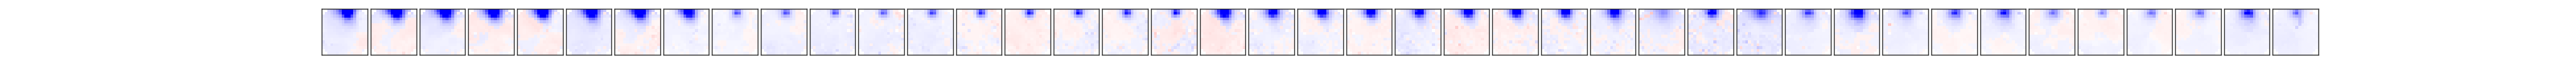

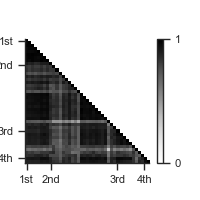

1 8
[4.8 5.5 5.2 5.1 4.1 4.4 5.3 2.8]


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


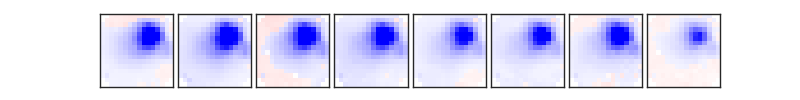

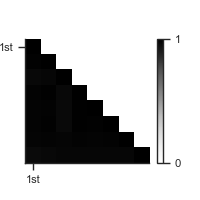

2 16
[2.5 2.7 2.5 2.3 2.5 2.2 2.2 2.4 1.8 1.6 1.4 1.6 1.3 1.5 1.4 1.2]


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


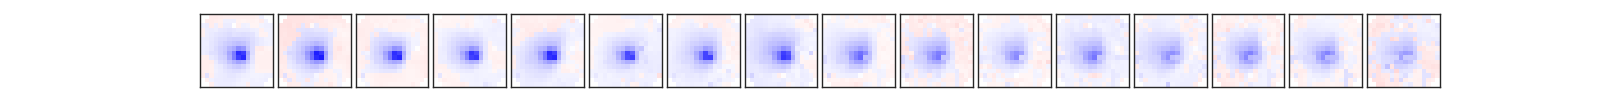

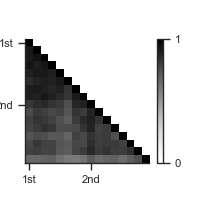

3 8
[2.2 2.9 2.  1.5 1.5 1.6 1.4 2.2]


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


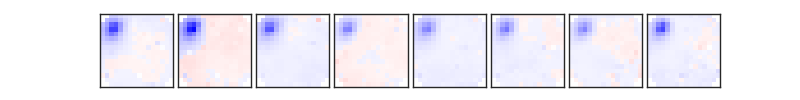

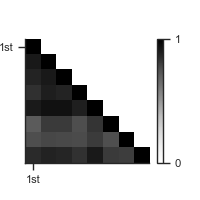

4 2
[3.1 2.9]


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


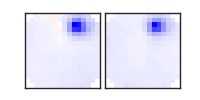

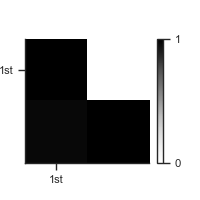

5 3
[1.7 3.3 3.2]


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


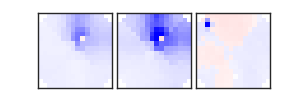

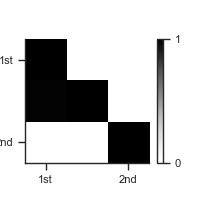

6 15
[3.1 2.8 4.  4.  3.7 3.4 2.8 1.4 1.2 1.8 1.4 1.4 1.1 1.1 1.2]


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


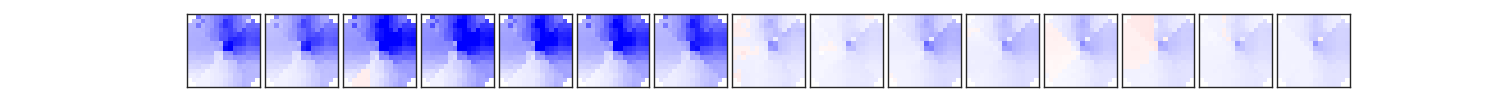

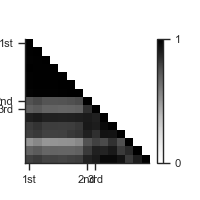

7 79
[4.2 3.8 3.3 3.5 2.4 2.7 2.2 2.  1.7 1.6 1.9 1.7 1.3 1.5 1.2 1.6 1.5 1.3
 1.3 1.5 1.2 4.1 2.8 3.  3.2 3.9 3.5 3.2 2.6 2.6 3.1 3.1 2.8 2.7 2.5 2.4
 2.2 2.8 3.2 3.9 2.9 2.6 2.7 2.1 2.6 2.4 2.1 2.1 2.1 2.2 2.1 1.5 1.4 1.8
 1.1 2.6 2.5 2.7 2.2 2.9 1.3 1.5 2.  5.1 6.3 4.7 4.5 4.6 4.6 4.4 6.4 4.6
 6.5 5.8 6.5 6.7 6.4 2.9 6.2]


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


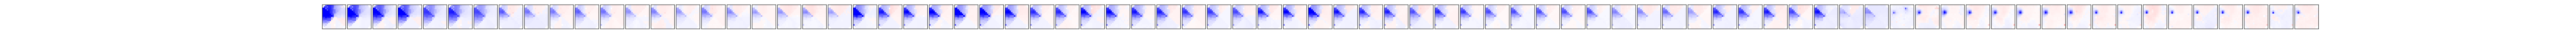

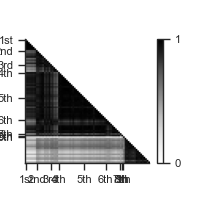

In [8]:
# ERP plots
for idx in range(len(erp_sites)):
    maps = erp_sites[idx]
    print(idx, len(maps))
    plot_spatial_drive_maps(maps, (1,len(maps)), (1,1), cmap='bwr', clim=(-3,3), elec_data=True,
                            interp=True, grid_size=(16,16), interp_method='cubic', threshold_dist=1.0, 
                            nan_color='white', label_mode=None)

    filename = f'stim_longitude_site_{longitude_sites[idx]}.svg'
    aopy.visualization.savefig(fig_dir, filename)
    volume = np.max(np.abs(maps), axis=1)
    print(np.round(volume,1))

    plot_correlation_matrix(erp_sites[idx], day_sites[idx])
    plt.show()

20


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


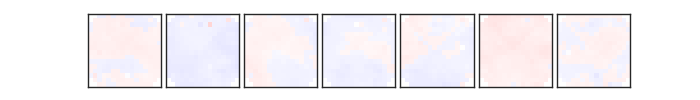

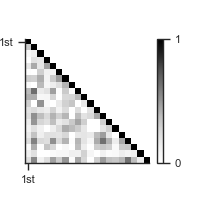

In [9]:
# Null maps for comparison
maps = b_all_sites['erp_null_maps'][int(longitude_sites[1][1:])-1]
print(len(maps))
plot_spatial_drive_maps(maps[::3], (1,len(maps[::3])), (1,1), cmap='bwr', clim=(-3,3), elec_data=True,
                        interp=True, grid_size=(16,16), interp_method='cubic', threshold_dist=1.0, 
                        nan_color='white', label_mode=None)
plot_correlation_matrix(maps, np.arange(len(maps)))

20


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


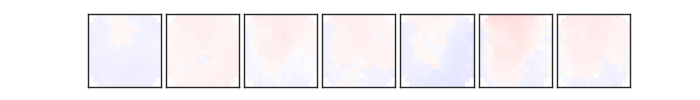

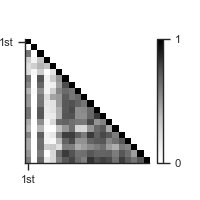

In [10]:
maps = a_all_sites['erp_null_maps'][int(longitude_sites[2][1:])-1]
print(len(maps))
plot_spatial_drive_maps(maps[::3], (1,len(maps[::3])), (1,1), cmap='bwr', clim=(-3,3), elec_data=True,
                        interp=True, grid_size=(16,16), interp_method='cubic', threshold_dist=1.0, 
                        nan_color='white', label_mode=None)
plot_correlation_matrix(maps, np.arange(len(maps)))

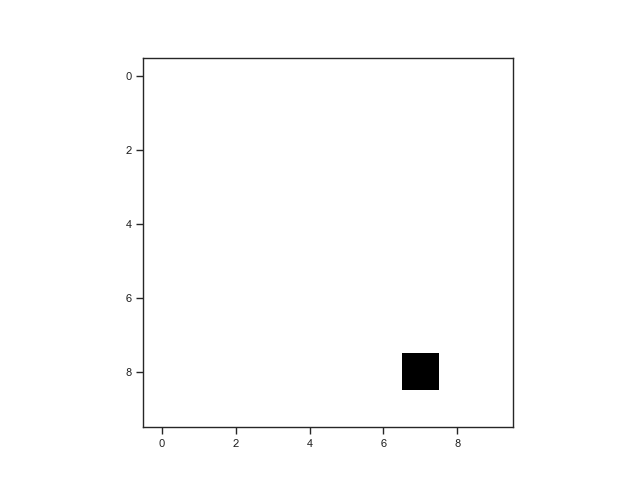

In [11]:
def get_single_implant_mask(start_day, end_day, n_days):
    mask = np.zeros((n_days, n_days), dtype=bool)
    mask[start_day+1:end_day,start_day] = 1
    return mask

ncc = np.ones((10,10))
mask = get_single_implant_mask(7,9,10)
ncc[~mask] = 0
im = plt.imshow(ncc, cmap='Grays', vmin=0., vmax=1)

def get_per_implant_comparisons(ncc, implant_days, min_days=2, max_gap=5):
    # print(implant_days)
    implant = convert_days_to_implant(implant_days, max_gap)
    # print(implant)
    reps, chg_idx = aopy.utils.count_repetitions(implant)
    # print(chg_idx)
    # print(reps)
    slices = list(zip(chg_idx, chg_idx+reps))
    # print(slices)
    # print(len(implant))
    # plt.figure()
    nccs = []
    days = []
    for st, ed in slices:
        if (ed - st) < min_days:
            continue
        # print(st, ed, len(implant))
        mask = get_single_implant_mask(st,ed,len(implant))
        # print(ncc.shape, mask.shape)
        nccs.append(ncc[mask])
        days.append(implant_days[st:ed])
        
    return nccs, days
    # im = plt.imshow(ncc, cmap='Grays', vmin=0., vmax=1)

# get_per_implant_comparisons(np.ones((33,33)), day_sites[0])


In [24]:
# Summarize
def summarize_correlation_matrices_line(site_data_maps, stim_sites, implant_days, 
                                        ax=None, **kwargs):
    if ax is None:
        ax = plt.gca()
    ax.set_facecolor('#EAEAF2')

    rows = []
    ticks = []
    labels = []
    for idx in range(len(site_data_maps)):
        ncc, shifts = calc_spatial_data_correlation(site_data_maps[idx], elec_pos, interp=True, grid_size=(16,16), interp_method='linear')
        per_implant, _ = get_per_implant_comparisons(ncc, implant_days[idx][:len(ncc)])
        ticks.append(len(rows))
        labels.append(stim_sites[idx])
        rows.extend(per_implant)
    
    sort_idx = np.argsort([len(seg) for seg in rows])
    nd = max(len(seg) for seg in rows)
    ns = len(rows)
    mat = np.full((nd, ns), np.nan)
    for idx, seg in enumerate(rows):
        mat[:len(seg), idx] = seg
    rows = mat[:,sort_idx]
    ticklabels = [1, ns]
    im = aopy.visualization.plot_image_by_time(np.arange(len(rows)), rows, cmap='Grays')
    im.set_clim(0,1)
    ax.set_xlabel('days')
    ax.set_xticks([0.5,8.5,16.5], labels=[2,10,18])
    ax.set_yticks(np.array(ticklabels)-0.5, ticklabels)
    ax.set_ylabel('implant sorted\nby length')
    pcm = plt.colorbar(im)
    pcm.set_label('$R^2$ day $n$ vs. day 1')
    pcm.set_ticks([0,1])
    sns.despine(ax=ax)


def summarize_correlation_matrices_box(site_data_maps, stim_sites, implant_days, null_maps=None, 
                                       box_color='w', ax=None):
    if ax is None:
        ax = plt.gca()
        
    df = None
    for idx in range(len(site_data_maps)):
        ncc, shifts = calc_spatial_data_correlation(site_data_maps[idx], elec_pos, interp=True, grid_size=(16,16), interp_method='linear')
        per_implant, _ = get_per_implant_comparisons(ncc, implant_days[idx][:len(ncc)])
        nonnan = np.concatenate(per_implant)
        df = pd.concat([df, pd.DataFrame({
            "value": nonnan.flatten(),
            "subject": stim_sites[idx][0],
            "site": [idx+1] * len(nonnan),
            "cat": "data",
        })])
    
    if null_maps is not None:

        for idx in range(len(null_maps)):
            print(idx, len(null_maps[idx]))
            ncc, shifts = calc_spatial_data_correlation(null_maps[idx], elec_pos, interp=True, grid_size=(16,16), interp_method='linear')
            nonnan = ncc[0,1:]
            df = pd.concat([df, pd.DataFrame({
                "value": nonnan.flatten(),
                "subject": stim_sites[idx][0],
                "site": [idx+1] * len(nonnan),
                "cat": "null",
            })])

    # xmin = 0
    # for subject, df_n in df_null.groupby("site"):
    #     nonnan = df_n["value"]
    #     xmax = xmin + len(np.unique(df_n['site']))/len(np.unique(df['site']))
    #     plt.axhline(np.quantile(nonnan, 0.25), xmin, xmax, linestyle='--', color='gray')
    #     plt.axhline(np.median(nonnan), xmin, xmax, color='gray')
    #     plt.axhline(np.quantile(nonnan, 0.75), xmin, xmax, linestyle='--', color='gray')        
    #     xmin = xmax
    
    df.reset_index(drop=True, inplace=True)
    sns.boxplot(data=df, x="site", y="value", hue="cat", legend=False, 
                palette=[box_color, 'gray'], width=0.6, ax=ax)        
    
    for subject in ['b', 'a']:
        subj = df['subject'] == subject
        data = df['cat'] == 'data'
        null = df['cat'] == 'null'
        result = stats.mannwhitneyu(df.loc[subj & data, 'value'], 
                                    df.loc[subj & null, 'value'],
                                    nan_policy='omit')
        print(subject, len(df.loc[subj & data]), len(df.loc[subj & null]), result)
        
    sites = []
    for s in stim_sites:
        sites.append(s[1:])
    ax.set_xticks(range(len(sites)))
    ax.set_xticklabels(sites)
    ax.set_ylim(0,1)
    ax.set_yticks([0,1])
    ax.set_ylabel('$R^2$ day $n$ vs. day 1')
    sns.despine(ax=ax)

    return df
        



In [25]:
# Save implant information for trial sweep
min_days = 2
implant_ncc = []
implant_subj = []
implant_site = []
implant_days = []
for idx in range(len(erp_sites)):
    stim_site = longitude_sites[idx]
    ncc, shifts = calc_spatial_data_correlation(erp_sites[idx], elec_pos, interp=True, grid_size=(16,16), interp_method='linear')
    per_implant, days = get_per_implant_comparisons(ncc, day_sites[idx][:len(ncc)], min_days=min_days)
    implant_ncc.extend(per_implant)
    implant_site.extend([int(stim_site[1:])]*len(per_implant))
    implant_subj.extend(['beignet' if stim_site[0] == 'b' else 'affi']*len(per_implant))
    implant_days.extend(days)
    
print(len(implant_ncc))
assert len(implant_ncc) == len(implant_site) == len(implant_subj) == len(implant_days)

print(implant_days[0], implant_site[0], implant_subj[0], implant_ncc[0])

print(implant_site)

# Save to a pickle file
aopy.data.pkl_write(f'trial_sz_implants_{version}.pkl',
                    (implant_days, implant_site, implant_subj, implant_ncc), postproc_dir)

# implant_days, implant_site, implant_subj, implant_ncc = aopy.data.pkl_read(
#     f'trial_sz_implants_{version}.pkl', postproc_dir)


19
[datetime.date(2022, 2, 15) datetime.date(2022, 2, 16)
 datetime.date(2022, 2, 17) datetime.date(2022, 2, 18)
 datetime.date(2022, 2, 19) datetime.date(2022, 2, 20)
 datetime.date(2022, 2, 21) datetime.date(2022, 2, 22)] 11 beignet [0.97542186 0.98574265 0.96564241 0.9680472  0.9826199  0.97453301
 0.97557944]
[11, 11, 11, 11, 7, 15, 15, 28, 6, 13, 14, 14, 29, 29, 29, 29, 29, 29, 29]


### Plot for figure 1

[ 0  8 30 39]
0
7
8
29
2022-03-15 2022-02-22 21 days, 0:00:00
30
40
2022-06-08 2022-04-14 55 days, 0:00:00


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')
/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


0 20
1 20
2 20
3 20
4 20
5 20
6 20
7 20
b 65 76 MannwhitneyuResult(statistic=np.float64(4940.0), pvalue=np.float64(1.710656750232007e-24))
a 84 76 MannwhitneyuResult(statistic=np.float64(6176.0), pvalue=np.float64(2.0721170979660434e-24))


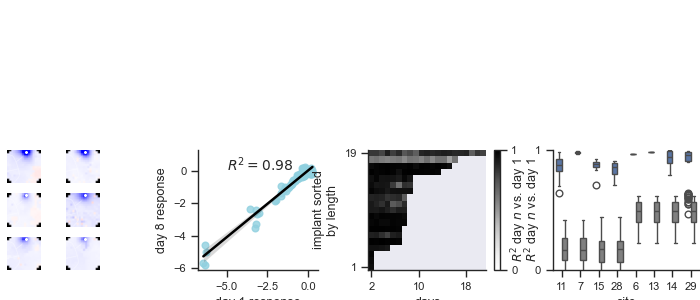

In [26]:
maps = erp_sites[0]
stim_site = longitude_sites[0][1:]
implant = convert_days_to_implant(day_sites[0])
reps, chg_idx = aopy.utils.count_repetitions(implant)
print(chg_idx)

subject = 'beignet'
chamber = 'lm1'
theta = 0

fig = plt.figure(figsize=(7,3))

grid = GridSpec(3, 12)
plt.subplots_adjust(left=0, right=1, top=0.5, bottom=0.1, wspace=0.25, hspace=0.3)

for implant_idx in range(3):
    map_idx = chg_idx[implant_idx]
    print(map_idx)
    ax = fig.add_subplot(grid[implant_idx,0]).axis('off')
    plot_annotated_spatial_drive_map_stim(maps[map_idx], stim_site, subject, chamber, theta, 
                                          cmap='bwr', clim=(-3,3), elec_data=True,
                                          interp=True, grid_size=(16,16), interp_method='cubic', 
                                          threshold_dist=1.0, colorbar=False)
    
    map_idx = chg_idx[implant_idx+1]-1 if implant_idx < 2 else len(maps)-1
    print(map_idx)
    ax = fig.add_subplot(grid[implant_idx,1]).axis('off')
    plot_annotated_spatial_drive_map_stim(maps[map_idx], stim_site, subject, chamber, theta, 
                                          cmap='bwr', clim=(-3,3), elec_data=True,
                                          interp=True, grid_size=(16,16), interp_method='cubic', 
                                          threshold_dist=1.0, colorbar=False)
    if implant_idx > 0:
        day1 = day_sites[0][chg_idx[implant_idx]]
        day2 = day_sites[0][chg_idx[implant_idx]-1]
        time_inbetween = day1 - day2
        print(day1, day2, time_inbetween)

    
plt.subplot(1,4,2)
# plot_correlation_matrix(erp_sites[0], day_sites[0], ax=plt.gca())
df = pd.DataFrame({"day 1 response": maps[0].ravel(), "day 8 response": maps[7].ravel()})
sns.regplot(data=df, x="day 1 response", y="day 8 response", color=color_monkey_1, line_kws={"color": "black"})
plt.axis('equal')
plt.axis('square')
sns.despine()
slope, intercept, r, p, sterr = stats.linregress(x=df["day 1 response"], y=df["day 8 response"])
plt.text(-5, 0, f'$R^2 = {np.round(r,2)}$')

plt.subplot(1,4,3)
summarize_correlation_matrices_line(erp_sites, longitude_sites, day_sites)

plt.subplot(1,4,4)
site_idx_a = [int(s[1:])-1 for s in longitude_sites if s[0] == 'a']
site_idx_b = [int(s[1:])-1 for s in longitude_sites if s[0] == 'b']
null_maps = [b_all_sites['erp_null_maps'][idx] for idx in site_idx_b] + [a_all_sites['erp_null_maps'][idx] for idx in site_idx_a]
summarize_correlation_matrices_box(erp_sites, longitude_sites, day_sites, null_maps, 'b')

filename = f'opto_longitude_summary.svg'
aopy.visualization.savefig(fig_dir, filename)


### Connectivity

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


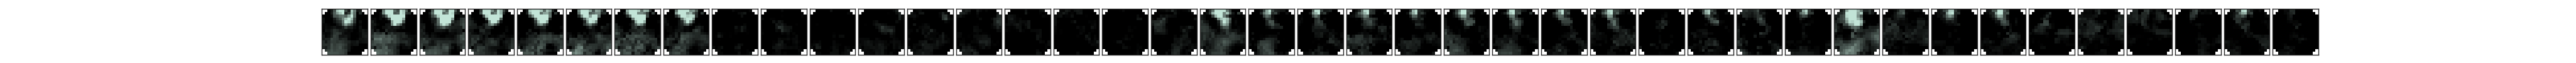

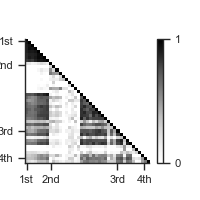

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


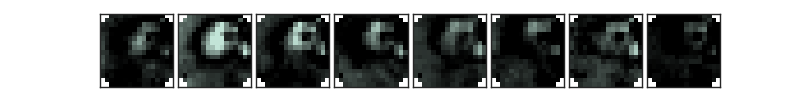

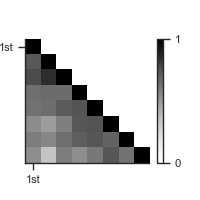

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


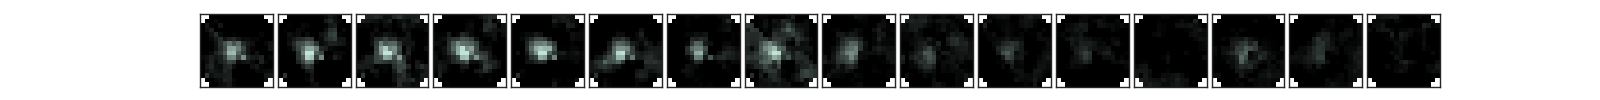

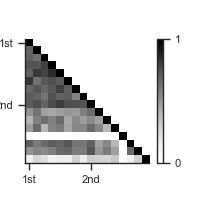

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


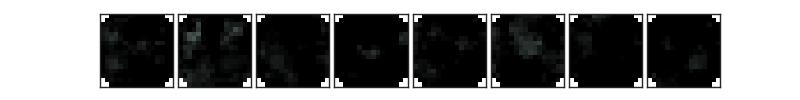

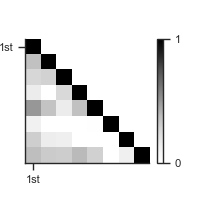

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


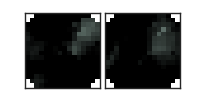

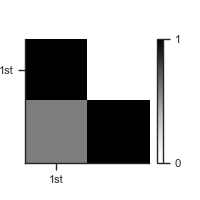

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


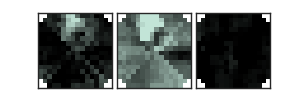

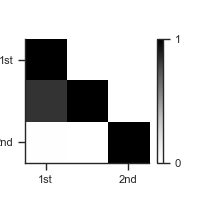

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


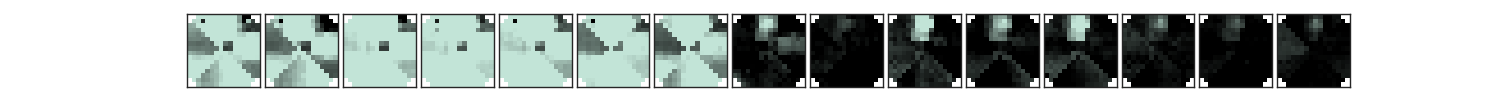

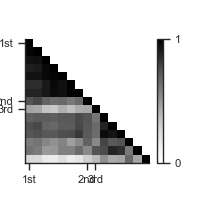

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


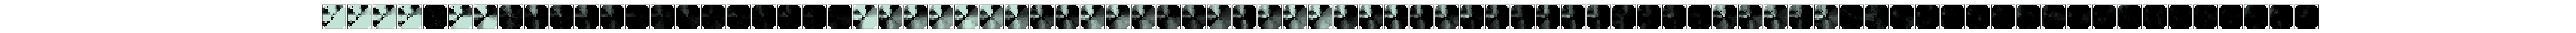

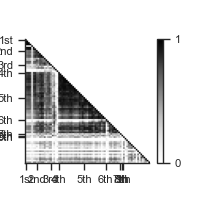

In [15]:
# SLIC plots
for idx in range(len(slic_sites)):
    maps = slic_sites[idx]
    plot_spatial_drive_maps(maps, (1,len(maps)), (1,1), cmap=cmap_slic, clim=(0,0.1), elec_data=True,
                            interp=True, grid_size=(16,16), interp_method='cubic', threshold_dist=1.0, 
                            nan_color='white', label_mode=None)

    filename = f'coh_longitude_site_{longitude_sites[idx]}.svg'
    aopy.visualization.savefig(fig_dir, filename)
    
    plot_correlation_matrix(slic_sites[idx], day_sites[idx]) 
    
    plt.show()

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')
/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2058: RuntimeWarning: invalid value encountered in divide
  flat_maps /= np.linalg.norm(flat_maps, axis=1, keepdims=True)


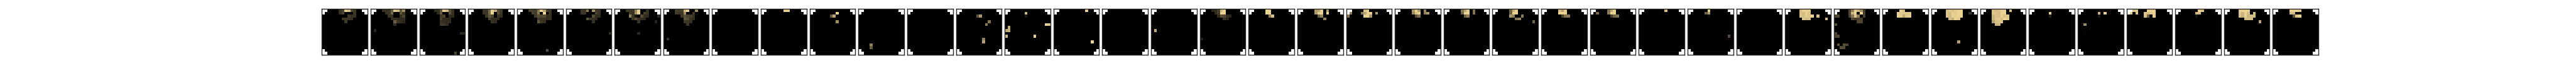

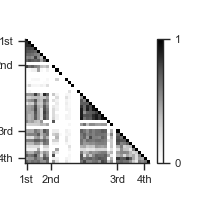

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


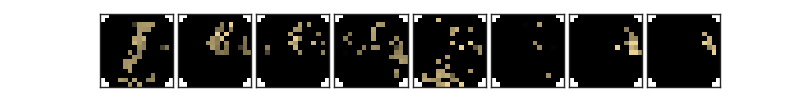

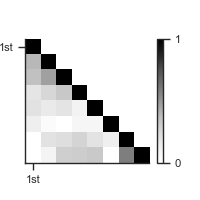

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')
/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2058: RuntimeWarning: invalid value encountered in divide
  flat_maps /= np.linalg.norm(flat_maps, axis=1, keepdims=True)


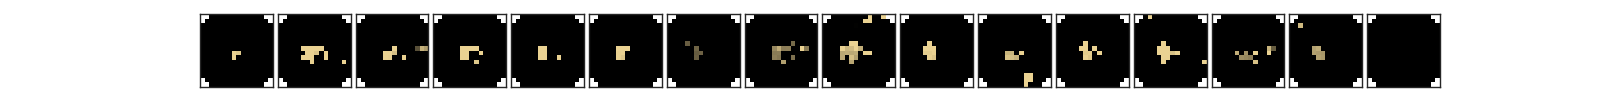

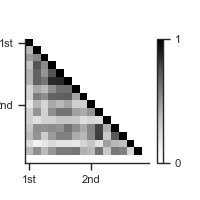

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')
/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2058: RuntimeWarning: invalid value encountered in divide
  flat_maps /= np.linalg.norm(flat_maps, axis=1, keepdims=True)


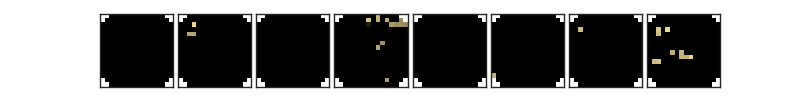

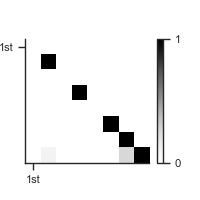

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


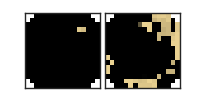

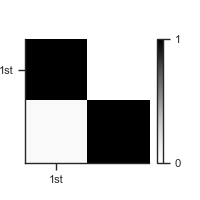

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')
/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2058: RuntimeWarning: invalid value encountered in divide
  flat_maps /= np.linalg.norm(flat_maps, axis=1, keepdims=True)


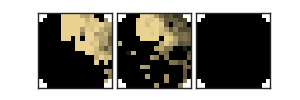

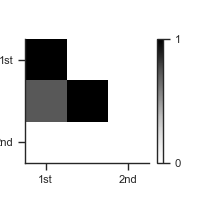

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


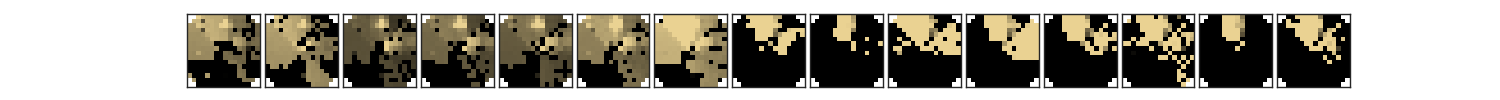

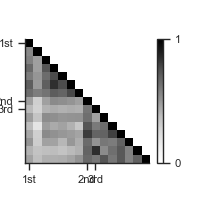

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')
/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2058: RuntimeWarning: invalid value encountered in divide
  flat_maps /= np.linalg.norm(flat_maps, axis=1, keepdims=True)


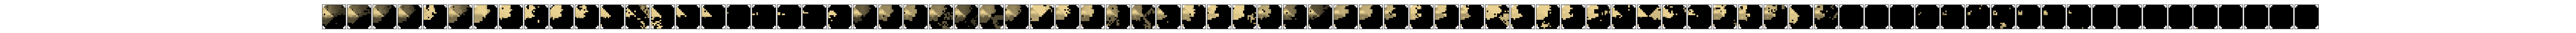

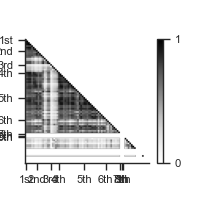

In [16]:
# AccLLR plots
for idx in range(len(slic_sites)):
    maps = accllr_sites[idx]
    plot_spatial_drive_maps(maps, (1,len(maps)), (1,1), cmap=cmap_accllr, clim=(0,1), elec_data=True,
                            interp=True, grid_size=(16,16), interp_method='cubic', threshold_dist=1.0, 
                            nan_color='white', label_mode=None)

    filename = f'accllr_longitude_site_{longitude_sites[idx]}.svg'
    aopy.visualization.savefig(fig_dir, filename)
    
    plot_correlation_matrix(accllr_sites[idx], day_sites[idx]) 
    
    plt.show()

In [35]:
accllr_null_maps = []
slic_null_band = []
gc_null_band = []
for idx in site_idx_a:
    slic_null_maps = a_all_sites['slic_null_maps'][idx][:38]
    slic_null_band.append([calc_tfr_mean(freqs, time, m, band) for m in slic_null_maps])
    gc_null_maps = a_all_sites['gc_null_maps'][idx]
    gc_null_band.append([calc_tfr_mean(freqs, time, m, band) for m in gc_null_maps])
    accllr_null_maps.append(a_all_sites['itpc_null_maps'][idx])
for idx in site_idx_b:
    slic_null_maps = b_all_sites['slic_null_maps'][idx]
    slic_null_band.append([calc_tfr_mean(freqs, time, m, band) for m in slic_null_maps])
    gc_null_maps = b_all_sites['gc_null_maps'][idx]
    gc_null_band.append([calc_tfr_mean(freqs, time, m, band) for m in gc_null_maps])
    accllr_null_maps.append(b_all_sites['itpc_null_maps'][idx])


### Plots for figure 3

In [36]:
var = []
volume = []
mean_slic = []
mean_gc = []
nccs_slic = []
nccs_gc = []
for idx in range(len(erp_sites)):
    stim_site = longitude_sites[idx]
    implant = convert_days_to_implant(day_sites[idx])
    reps, chg_idx = aopy.utils.count_repetitions(implant)
    slices = list(zip(chg_idx, chg_idx+reps))
    for st, ed in slices:
        vol = np.mean(abs(np.mean(erp_sites[idx][st:ed], axis=1)))
        if vol > 300:
            continue
        volume.append(vol)
        var.append(np.mean(var_sites[idx][st:ed]))
        mask = get_single_implant_mask(st,ed,len(implant))
        mean_slic.append(np.mean(slic_sites[idx][st:ed]))
        ncc, shifts = calc_spatial_data_correlation(slic_sites[idx], elec_pos, interp=True, grid_size=(16,16), interp_method='linear')
        nccs_slic.append(np.mean(ncc[mask]))
        mean_gc.append(np.mean(gc_sites[idx][st:ed]))
        ncc, shifts = calc_spatial_data_correlation(gc_sites[idx], elec_pos, interp=True, grid_size=(16,16), interp_method='linear')
        nccs_gc.append(np.mean(ncc[mask]))
mean_slic_norm = (mean_slic - np.min(mean_slic)) / (np.max(mean_slic) - np.min(mean_slic))
mean_gc_norm = (mean_gc - np.min(mean_gc)) / (np.max(mean_gc) - np.min(mean_gc))
group = ["SLIC"] * len(nccs_slic) + ["GP"] * len(nccs_gc)
summary_df = pd.DataFrame({"volume": volume + volume, 
                           "variance": var + var,
                           "mean": list(mean_slic_norm) + list(mean_gc_norm),
                           "correlation": nccs_slic + nccs_gc,
                           "group": group})

/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


0
7
8
29
30
40
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False]


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


0 38
1 38
2 38
3 38
4 40
5 40
6 40
7 40
b 65 148 MannwhitneyuResult(statistic=np.float64(8599.0), pvalue=np.float64(5.871003676758494e-20))
a 84 156 MannwhitneyuResult(statistic=np.float64(11854.0), pvalue=np.float64(4.932600936569076e-25))


/home/aolab/miniconda3/envs/ecog_opto_connectivity/lib/python3.12/site-packages/aopy/analysis/base.py:2054: UserWarning: Removing 12 NaN values in data maps
  warnings.warn(f'Removing {np.sum(mask)} NaN values in data maps')


0 20
1 20
2 20
3 20
4 20
5 20
6 20
7 20
b 65 76 MannwhitneyuResult(statistic=np.float64(3144.0), pvalue=np.float64(0.005342683049763525))
a 84 76 MannwhitneyuResult(statistic=np.float64(2723.0), pvalue=np.float64(0.10941814857013925))


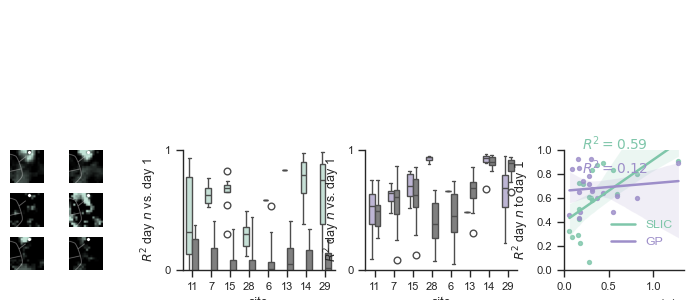

In [37]:
maps = slic_sites[0]
stim_site = int(longitude_sites[0][1:])
implant = convert_days_to_implant(day_sites[0])
reps, chg_idx = aopy.utils.count_repetitions(implant)

subject = 'beignet'
chamber = 'lm1'
theta = 0

fig = plt.figure(figsize=(7,3))

grid = GridSpec(3, 12, wspace=0.1, hspace=0.3)
plt.subplots_adjust(left=0, right=1, top=0.5, bottom=0.1)

for implant_idx, clim in zip(range(3), [0.1, 0.02, 0.03]):
    map_idx = chg_idx[implant_idx]
    print(map_idx)
    ax = fig.add_subplot(grid[implant_idx,0]).axis('off')
    plot_annotated_spatial_drive_map_stim(maps[map_idx], stim_site, subject, chamber, theta, 
                                          cmap=cmap_slic, clim=(0,clim), elec_data=True,
                                          interp=True, grid_size=(16,16), interp_method='cubic', 
                                          threshold_dist=1.0, colorbar=False)
    
    map_idx = chg_idx[implant_idx+1]-1 if implant_idx < 2 else len(maps)-1
    print(map_idx)
    ax = fig.add_subplot(grid[implant_idx,1]).axis('off')
    plot_annotated_spatial_drive_map_stim(maps[map_idx], stim_site, subject, chamber, theta, 
                                          cmap=cmap_slic, clim=(0,clim), elec_data=True,
                                          interp=True, grid_size=(16,16), interp_method='cubic', 
                                          threshold_dist=1.0, colorbar=False)

colors = sns.color_palette("Dark2", n_colors=4)

plt.subplot(1,4,2)
print(np.any(np.isnan(slic_null_band[0]), axis=1))
df_slic = summarize_correlation_matrices_box(slic_sites, longitude_sites, day_sites, slic_null_band,
                                            box_color=color_slic)

plt.subplot(1,4,3)
df_gc = summarize_correlation_matrices_box(gc_sites, longitude_sites, day_sites, gc_null_band,
                                          box_color=color_granger)

plt.subplot(1,4,4,box_aspect=1)
plt.gca().set_prop_cycle(color=[color_slic_text, color_granger_text])
slic_df = summary_df[summary_df["group"] == "SLIC"].dropna()
gc_df = summary_df[summary_df["group"] == "GP"].dropna()
sns.regplot(data=slic_df, x="volume", y="correlation", scatter_kws={"s": 8})
sns.regplot(data=gc_df, x="volume", y="correlation", scatter_kws={"s": 8}, )
import scipy
_, _, r1, p1, _ = scipy.stats.linregress(x=slic_df["volume"], y=slic_df["correlation"])
_, _, r2, p2, _ = scipy.stats.linregress(x=gc_df["volume"], y=gc_df["correlation"])
plt.text(0.2, 1, f'$R^2 = {np.round(r1,2)}$', color=color_slic_text)
plt.text(0.2, 0.8, f'$R^2 = {np.round(r2,2)}$', color=color_granger_text)
obj = plt.gca().get_lines()
plt.legend(obj, ['SLIC', 'GP'], bbox_to_anchor=(0.3,0.1), loc='lower left', 
           labelcolor='linecolor', markerscale=0, frameon=False)
plt.xlabel('mean response ($\\sigma$)\n(from stim)')
plt.ylabel(f'$R^2$ day $n$ to day $1$')
plt.xticks([0,0.5,1])
plt.ylim(0,1)
sns.despine()

filename = f'connectivity_longitude_summary.svg'
aopy.visualization.savefig(fig_dir, filename)


## Sweep number of trials

In [ ]:
# Read the data
data = aopy.data.pkl_read(f'trial_sz_{version}.pkl', postproc_dir)
trial_sizes = data['trial_sizes']
data['accllr'] = np.nan_to_num(data['accllr'])
data['itpc'] = np.nan_to_num(data['itpc'])
data['gc'] = np.nan_to_num(data['gc'])
data['gc_stim'] = np.nan_to_num(data['gc_stim'])
data['slic'] = np.nan_to_num(data['slic'])
mean_similarity_accllr = data['accllr']
mean_similarity_itpc = data['itpc']
mean_similarity_gc = data['gc']
mean_similarity_gc_stim = data['gc_stim']
mean_similarity_slic = data['slic']
erp_maps = data['erp']

In [ ]:
level = 0.75
near_max_slic = []
near_max_gc = []
near_max_gc_stim = []
near_max_accllr = []
max_slic = []
max_gc = []
max_gc_stim = []
max_accllr = []
rng_slic = []
rng_gc = []
rng_gc_stim = []
rng_accllr = []
for idx in range(len(mean_similarity_gc)):
    max_slic.append(np.nanmax(mean_similarity_slic[idx]))
    thr_slic = np.nanmax(mean_similarity_slic[idx]) * level
    idx_slic = np.where(mean_similarity_slic[idx] >= thr_slic)[0][0]
    near_max_slic.append(trial_sizes[idx_slic])
    rng_slic.append(np.nanmax(mean_similarity_slic[idx])-np.nanmin(mean_similarity_slic[idx]))
    
    max_gc.append(np.nanmax(mean_similarity_gc[idx]))
    thr_gc = np.nanmax(mean_similarity_gc[idx]) * level
    idx_gc = np.where(mean_similarity_gc[idx] >= thr_gc)[0][0]
    near_max_gc.append(trial_sizes[idx_gc])
    rng_gc.append(np.nanmax(mean_similarity_gc[idx])-np.nanmin(mean_similarity_gc[idx]))

    max_gc_stim.append(np.nanmax(mean_similarity_gc_stim[idx]))
    thr_gc_stim = np.nanmax(mean_similarity_gc_stim[idx]) * level
    idx_gc_stim = np.where(mean_similarity_gc_stim[idx] >= thr_gc_stim)[0][0]
    near_max_gc_stim.append(trial_sizes[idx_gc_stim])
    rng_gc_stim.append(np.nanmax(mean_similarity_gc_stim[idx])-np.nanmin(mean_similarity_gc_stim[idx]))

    max_accllr.append(np.nanmax(mean_similarity_accllr[idx]))
    rng_accllr.append(np.nanmax(mean_similarity_accllr[idx])-np.nanmin(mean_similarity_accllr[idx]))
    thr_accllr = np.nanmax(mean_similarity_accllr[idx]) * level
    print(thr_accllr)
    if np.isnan(thr_accllr):
        near_max_accllr.append(trial_sizes[-1])
        continue
    idx_accllr = np.where(mean_similarity_accllr[idx] >= thr_accllr)[0][0]
    near_max_accllr.append(trial_sizes[idx_accllr])
    
# AUC 
volume = [np.array(0) for _ in range(len(erp_maps))]
for idx in range(len(erp_maps)):
    volume[idx] = abs(np.sum(erp_maps[idx]))

In [ ]:
# Plot all together
colors = ['c', 'm']
plt.figure(figsize=(8,2))
for idx, label in enumerate(['slic', 'accllr', 'gc_stim', 'gc']):
    plt.subplot(1,4,idx+1)

    for mean_similarity, subj_idx in zip(data[label], data['subject']):
        subj_color = colors[1] if subj_idx=='affi' else colors[0]
        plt.plot(trial_sizes, mean_similarity, subj_color)
        plt.ylim(0,1)
        plt.xlabel('trials included')
        plt.ylabel('correlation')
        plt.title(label)
    
    sns.despine()

plt.tight_layout()

filename = f'trial_sizes_all.svg'
aopy.visualization.savefig(fig_dir, filename)

In [ ]:
# Plot max
plt.figure(figsize=(2,2), dpi=200)
data = np.array([max_slic, max_gc, max_accllr]).T
print(np.shape(data))
aopy.visualization.plot_boxplots(data, ['SLIC', 'Granger', 'Latency'], trendline=False)
plt.ylabel(f'max $R^2$ ')
sns.despine()
plt.tight_layout()

In [ ]:
# Plot range
plt.figure(figsize=(2,2), dpi=200)
data = np.array([rng_slic, rng_gc, rng_accllr]).T
print(np.shape(data))
aopy.visualization.plot_boxplots(data, ['SLIC', 'Granger', 'Latency'], trendline=False)
plt.ylabel(f'range $R^2$ ')
sns.despine()
plt.tight_layout()

In [ ]:
# Plot all together
plt.figure(figsize=(6,1.75), dpi=200)
plt.subplot(1,3,1)
plt.gca().set_prop_cycle(color=sns.color_palette("Dark2", n_colors=4))

for sub_data in [mean_similarity_slic[0], mean_similarity_gc[0], mean_similarity_accllr[0]]:
    plt.plot(trial_sizes, sub_data)
plt.xlim(0,500)
plt.ylim(0,1)
plt.xlabel('group size')
plt.ylabel('mean $R^2$')
plt.legend(['SLIC', 'Granger', 'Latency'], bbox_to_anchor=(0.,0.), loc='lower left', 
           labelcolor='linecolor', handlelength=1, frameon=False)
sns.despine()

plt.subplot(1,3,2)
data = np.array([rng_slic, rng_gc, rng_accllr]).T
print(np.shape(data))
aopy.visualization.plot_boxplots(data, ['SLIC', 'Granger', 'Latency'], trendline=False)
plt.ylabel(f'trials to reach \n{int(100*level)}% max $R^2$ ')
plt.ylim(0,1)
sns.despine()

plt.subplot(1,3,3)
plt.gca().set_prop_cycle(color=sns.color_palette("Dark2", n_colors=4))
plt.scatter(volume, rng_slic)
plt.scatter(volume, rng_gc)
plt.scatter(volume, rng_accllr)
plt.legend(['SLIC', 'Granger', 'Latency'], bbox_to_anchor=(0.1,0.0), loc='lower left', 
           labelcolor='linecolor', markerscale=0, frameon=False)
plt.xlabel('AUC (SD)')
plt.ylabel(f'trials to reach \n{int(100*level)}% max $R^2$')
plt.ylim(0,1)
plt.xlim(0,150)
sns.despine()

plt.subplots_adjust(top=1, bottom=0.3, left=0.2, right=1, wspace=0.5)

filename = f'trial_sizes_beignet.svg'
aopy.visualization.savefig(fig_dir, filename)